# Linear dependency removal
In this notebook, we are concerned with the following issue: given a basis of size $n$ which contains linearly dependent basis functions, how can we remove the linearly dependent basis functions to obtain a linearly independent subset of the original basis?

Theory tells that when building the transformation matrix $X$, we can procede via symmetric or cannonical orthogonalization:

$$
X_{symm} = U s^{-1/2} U^T
$$

And:

$$
X_{canon} = U s^{-1/2}
$$

However, since both of these methods require the inverse of the square root of the eigenvalues, they can be numerically unstable when the eigenvalues are small or close to zero. The solution is to directly discard the eigenvectors associated with the small eigenvalues, which correspond to the linearly dependent basis functions. As a consequence, there will be more rows than columns. 


In [1]:
from typing import Literal, Union

import numpy as np
from numpy.typing import NDArray

from py_mods.src.external.DIRAC_ME import build_S_V_W_T_from_h5
from py_mods.src.SCF.plot_utilities import plot_map

Starting from the original function:

In [2]:
def transformation_matrix(
    S: Union[NDArray[np.complex128], NDArray[np.float64]],
    method: Literal["canonical", "symmetric"] = "symmetric",
    verbose: bool = False,
    remove_lindep: bool = True,
    lindep_threshold: float = 1e-6,
) -> NDArray[np.float64]:
    """
    Calculate basis transformation matrix X.
    """
    assert method in [
        "canonical",
        "symmetric",
    ], "method must be 'canonical' or 'symmetric'"

    s, U = np.linalg.eigh(S)

    if remove_lindep:
        last_idx = 0

        for idx, eval in enumerate(s):
            last_idx = idx
            if eval > lindep_threshold:
                break

        if last_idx > 0:
            if method == "symmetric" and verbose:
                print(
                    "Removing linear dependencies implies canonical orthogonalization."
                )

            print(
                f"Removing {last_idx} linear dependencies with eigenvalues below {lindep_threshold:.2e} (largest removed eigenvalue: {s[last_idx-1]:.2e})"
            )

            U_truncated = U[:, last_idx:]
            s_truncated = s[last_idx:]

            s_root = np.diag(1.0 / np.sqrt(s_truncated))

            # This is no longer N x N, but rectangular NxM where M < N
            X = U_truncated @ s_root
            return X

    # Regular no lindep removal
    s_root = np.diag(1.0 / np.sqrt(s))

    if method == "symmetric":
        # U * s^{-1/2} * U^T
        X = U @ s_root @ U.conj().T
    elif method == "canonical":
        X = U @ s_root

    if verbose:
        transformed = X.conj().T @ S @ X
        print("Transformed S (should be Identity):\n", np.round(transformed, 10))

    return X

In [3]:
S, V, W, T = build_S_V_W_T_from_h5('../4c-scf/data/Mg_checkpoint.h5')

In [ ]:
X = transformation_matrix(S, remove_lindep=True)

Removing 6 linear dependencies with eigenvalues below 1.00e-06 (largest removed eigenvalue: 7.31e-10)


(398, 392)

In [5]:
print(f"Original dimension of S: {S.shape}")
print(f"Dimension after removal of linear dependencies:{(X.T @ V @ X).shape}")



Original dimension of S: (398, 398)
Dimension after removal of linear dependencies:(392, 392)


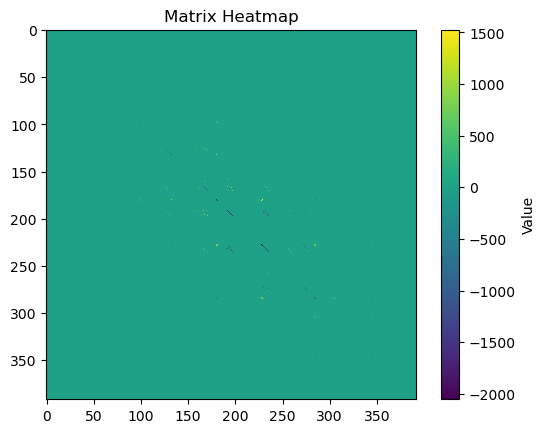

In [6]:
plot_map(X.T @ V @ X)

# Working with the reduced MO basis
Since the size of the AO basis and of the MO basis is not the same anymore, we need to adapt all the code that relies on the MO basis. Out of the box, since everything is performed based on einsums, the most worrying thing is the mismatch between the occupation vector and the MO basis.

S, V, W, T = build_S_V_W_T_from_h5(h5_filename)